# Introduction
This notebook tries to mimic the operation condition.
One should control the position of the motors and optics through the manipulation of the corresponding motion axes through the pre-defined functions.
In this way, one moves within the range permitted by the motor and respect the geometric constrain of the installation of the setup.

#### Definition
1. um, fs, keV
2. normal is pointing inwards the reflection surface
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z)
    i.e., The name in this code is x,y,z, using one convension. In the text, use the XPP convention 

np.fft(field) = spectrum

np.ifft(spectrum) = field

# Step 1: Ray Tracing Calculation

In [1]:
import time
import sys
sys.path.append("../../../../XRaySimulation")

import numpy as np
import matplotlib.pyplot as plt

# Level 1 dependence
from XRaySimulation import Pulse, DeviceSimu, util

# Level 2 dependece
import parser
import Controller

plt.rcParams.update({'font.size': 14})

In [2]:
# Create the experiment setup
exp = Controller.XppController_TG()

Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, ro

# Define functions on the fly

# Align the mono

### Mono before alignment

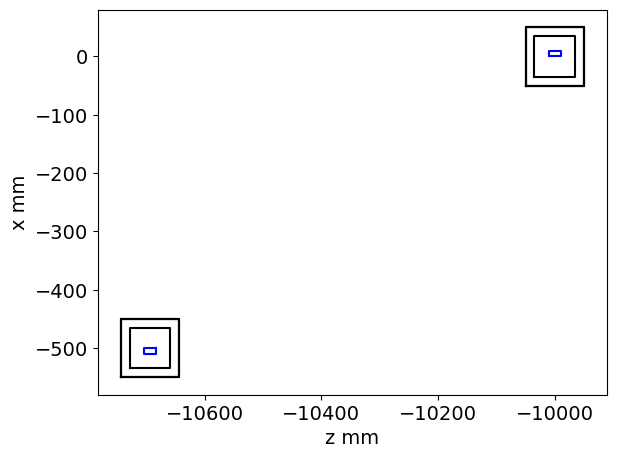

In [3]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.mono_t1.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t1.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.mono_t2.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t2.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

ax.set_aspect('equal')
ax.set_xlabel("z mm")
ax.set_ylabel("x mm")

plt.show()


### Mono after alignment

In [4]:
_ = exp.align_xpp_mono()

Motor moved to -17.88927 deg
Motor moved to -17.88927 deg
Motor moved to -17.89067 deg
Motor moved to -17.89083 deg


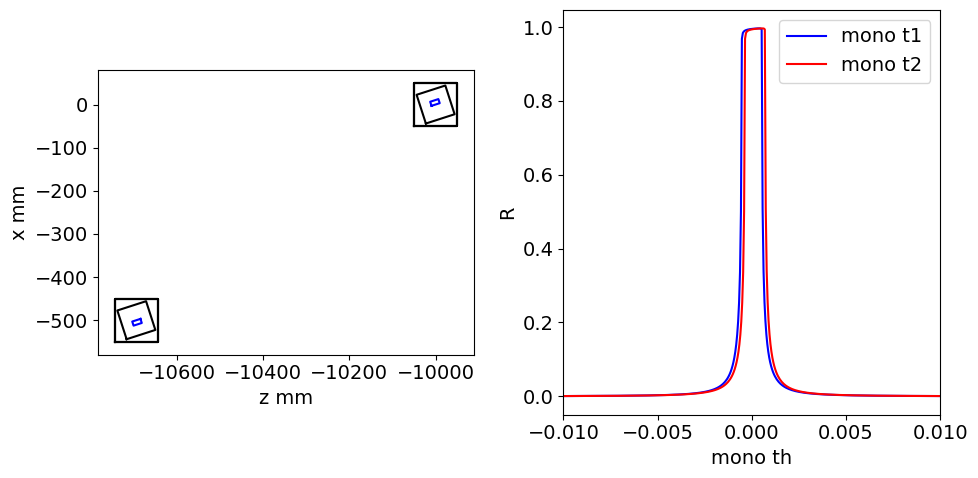

In [5]:
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.mono_t1.all_motors:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t1.all_optics:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.mono_t2.all_motors:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t2.all_optics:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

ax[0].set_aspect('equal')
ax[0].set_xlabel("z mm")
ax[0].set_ylabel("x mm")

ax[1].plot(np.rad2deg(exp.mono_t1_rocking[0]), exp.mono_t1_rocking[1], c='b', label='mono t1')
ax[1].plot(np.rad2deg(exp.mono_t2_rocking[0]), exp.mono_t1_rocking[1], c='r', label='mono t2')
ax[1].set_xlim([-0.01, 0.01])
ax[1].set_xlabel("mono th")
ax[1].set_ylabel("R")
ax[1].legend()

plt.tight_layout()
plt.show()


# Align the miniSD

### miniSD before alignment

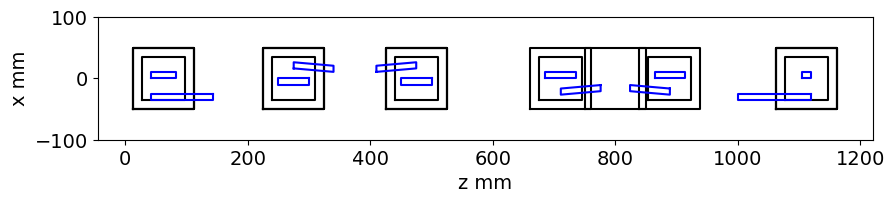

In [6]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.t1.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t1.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t2.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t2.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t3.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t3.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t45.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t45.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t6.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t6.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

#ax.set_xlim([6000, 8000])
ax.set_ylim([-100, 100])

ax.set_aspect('equal')
ax.set_xlabel("z mm")
ax.set_ylabel("x mm")

plt.show()

### miniSD after alignment

In [7]:
exp.align_miniSD()

Motor moved to 19.23525 deg
Motor moved to -19.23525 deg
Motor moved to 19.23525 deg
Motor moved to 19.23525 deg
Motor moved to -19.23525 deg
Motor moved to -19.23525 deg
Motor moved to 19.23606 deg
Motor moved to -19.23620 deg
Motor moved to -19.23616 deg
Motor moved to 19.23695 deg
Motor moved to 19.23691 deg
Motor moved to -19.23615 deg


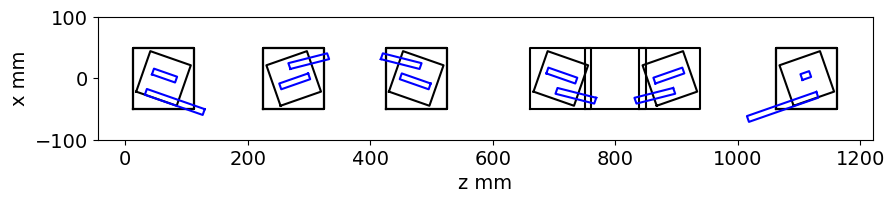

In [8]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.t1.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t1.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t2.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t2.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t3.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t3.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t45.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t45.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t6.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t6.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

ax.set_ylim([-100, 100])

ax.set_aspect('equal')
ax.set_xlabel("z mm")
ax.set_ylabel("x mm")

plt.show()

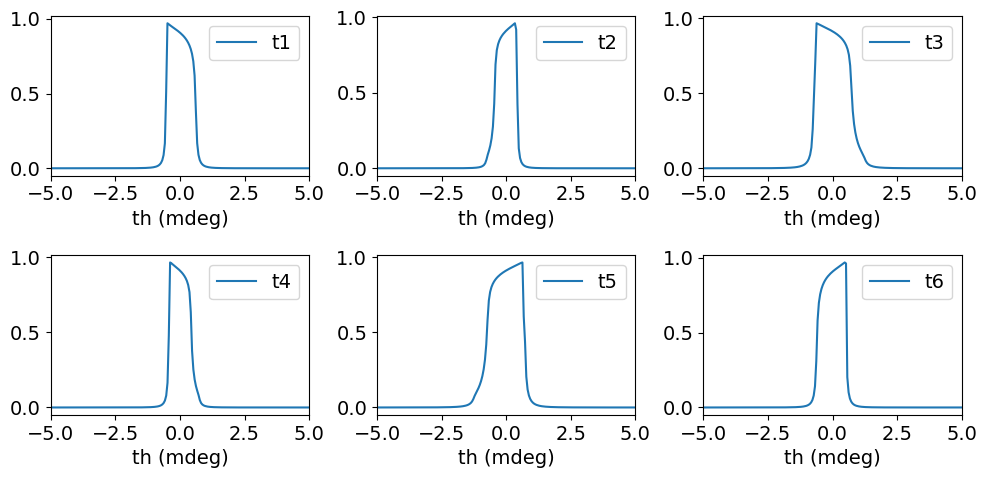

In [9]:
fig, ax = plt.subplots(ncols=3, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

record_to_plot = [exp.t1_rocking, exp.t2_rocking, exp.t3_rocking, exp.t4_rocking, exp.t5_rocking, exp.t6_rocking]
for idx in range(2):
    for idx2 in range(3):
        record = record_to_plot[idx2 + idx * 3]
        ax[idx, idx2].plot(np.rad2deg(record[0]) * 1000, record[1], label='t{}'.format(idx2 + 3 * idx + 1))
        ax[idx, idx2].set_xlabel('th (mdeg)')
        ax[idx, idx2].legend()
        ax[idx, idx2].set_xlim([-5, 5])


plt.tight_layout()
plt.show()

# Align the total reflection mirrors to the ideal angle

In [10]:
_ = exp.m1.pi_umv(np.deg2rad(0.1))

_ = exp.m2a.yaw_umv(np.deg2rad(0.3))
_ = exp.m2a.x_umv(-9.5e3)

_ = exp.m2b.yaw_umv(np.deg2rad(-0.3))
_ = exp.m2b.x_umv(9966.5113)

Motor moved to 0.10000 degree
Motor moved to 0.30000 degree
Motor moved to -9500.0000 um
Motor moved to -0.30000 degree
Motor moved to 9966.5113 um


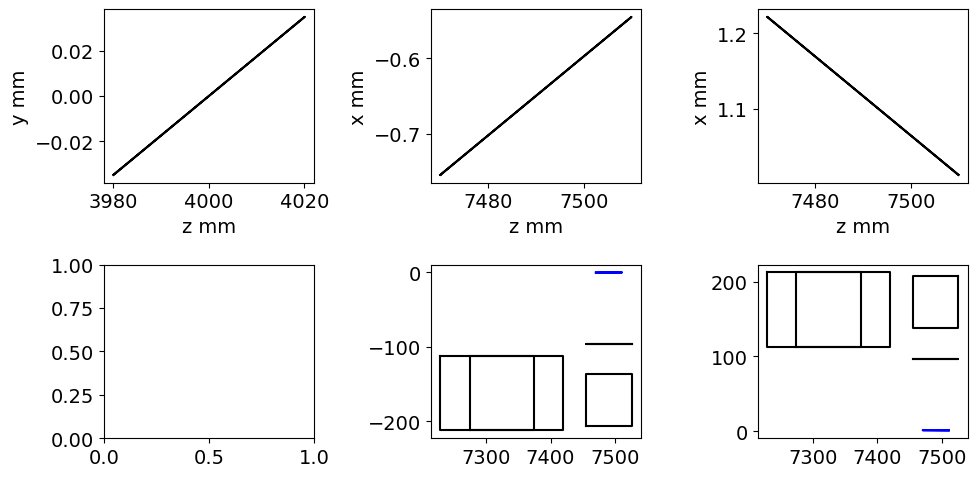

In [11]:
fig, ax = plt.subplots(ncols=3, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.m1.all_optics:
    ax[0,0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 0] / 1000, c='black')
ax[0,0].set_xlabel("z mm")
ax[0,0].set_ylabel("y mm")

for item in exp.m2a.all_optics:
    ax[0,1].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
ax[0,1].set_xlabel("z mm")
ax[0,1].set_ylabel("x mm")

for item in exp.m2b.all_optics:
    ax[0,2].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
ax[0,2].set_xlabel("z mm")
ax[0,2].set_ylabel("x mm")


for item in exp.m2a.all_motors:
    ax[1,1].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.m2a.all_optics:
    ax[1,1].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.m2b.all_motors:
    ax[1,2].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.m2b.all_optics:
    ax[1,2].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')


plt.tight_layout()
plt.show()


# Align the silicon crystal

In [12]:
# Get the theoretical Bragg angle
bragg_si111 = util.get_bragg_angle(wave_length=np.pi * 2 / exp.gaussian_pulse.klen0, plane_distance=Controller.si111['d'])

# Account for the 10 deg of the adaptor tilting
ang_diff = bragg_si111 - np.deg2rad(10)

# Rotate the crystal by the remaining angle
_ = exp.si.pi_umv(ang_diff)

# Get the rocking curve from this crystal
(angles1, reflect_sigma1,
 reflect_pi1, b_factor1, kout1) = DeviceSimu.get_rocking_curve_around_axis(
                                kin=exp.gaussian_pulse.k0,
                                scan_range=np.deg2rad(0.5),
                                scan_number=10 ** 4,
                                rotation_axis=exp.si.pi.rotation_axis,
                                h_initial=exp.si.optics.h,
                                normal_initial=exp.si.optics.normal,
                                thickness=exp.si.optics.thickness,
                                chi_dict=exp.si.optics.chi_dict, )

# Get the target bragg peak
fwhm, angle_adjust, index = util.get_fwhm(coordinate=angles1,
                                          curve_values=np.square(np.abs(reflect_pi1)),
                                          center=True,
                                          get_index=True)

# Move the crystal to the target path
_ = exp.si.pi_umv(target= exp.si.pi.control_location + angle_adjust)

Motor moved to 1.63904 degree
Motor moved to 1.63923 degree


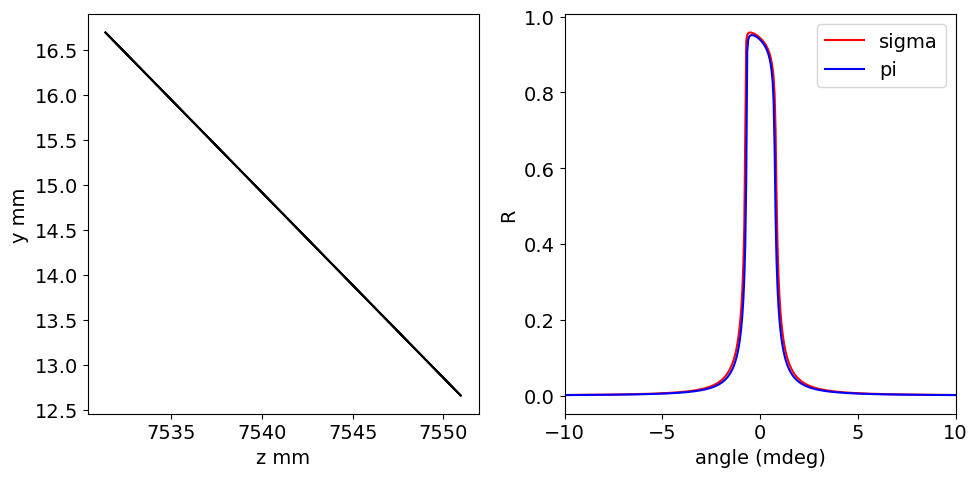

In [13]:
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.si.all_optics:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 0] / 1000, c='black')
ax[0].set_xlabel("z mm")
ax[0].set_ylabel("y mm")

ax[1].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_sigma1)), c='red', label='sigma')
ax[1].plot(np.rad2deg(angles1 - angle_adjust) * 1000, np.square(np.abs(reflect_pi1)), c='blue', label='pi')
ax[1].set_xlim([-10,10])
ax[1].set_xlabel("angle (mdeg)")
ax[1].set_ylabel("R")
ax[1].legend()

plt.tight_layout()
plt.show()


# Calculate the ray-tracing trajectory and finely adjust the position of the motors.

In [14]:
probe_path1 = exp.get_raytracing_trajectory(path="mono SD m1 yag")
probe_path2 = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path = exp.get_raytracing_trajectory(path="mono SD yag")
pump_path1 = exp.get_raytracing_trajectory(path="mono SD tga yag")
pump_path2 = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
pump_path3 = exp.get_raytracing_trajectory(path="mono SD tgb yag")
pump_path4 = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")

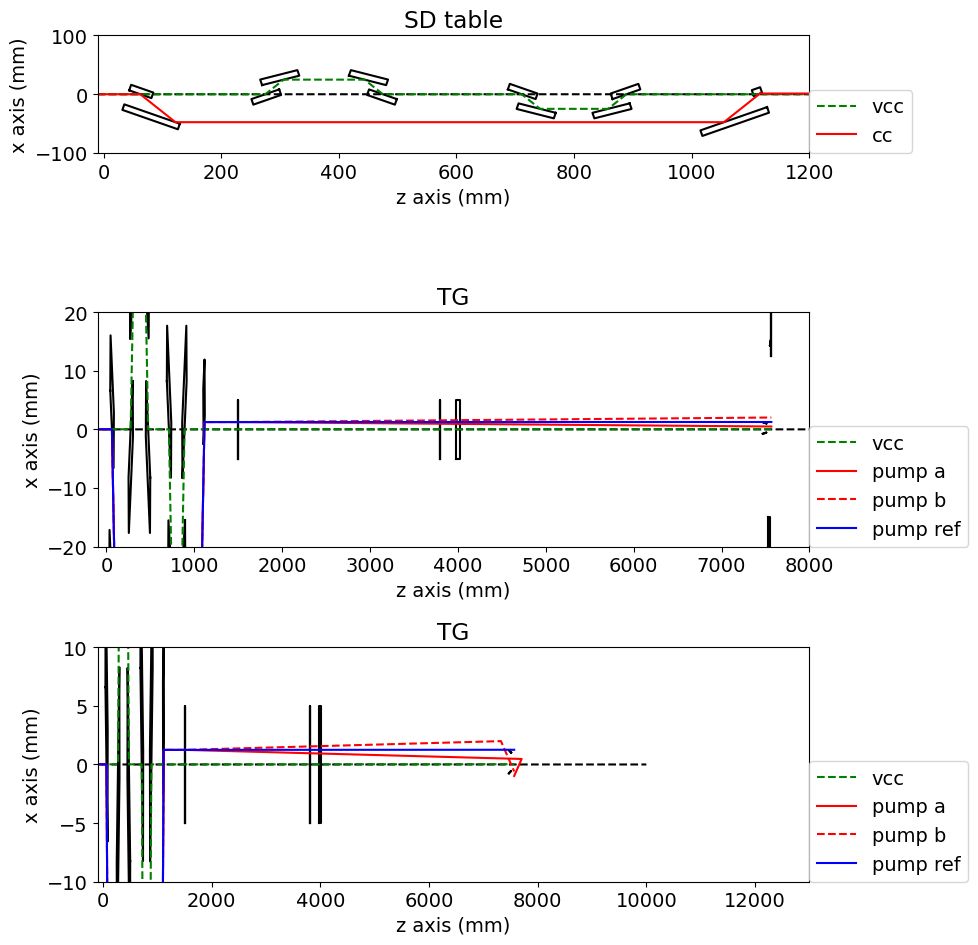

In [15]:
fig, axes = plt.subplots(ncols=1, nrows=3)

fig.set_figheight(10)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[0])

axes[0].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[0].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='cc')

axes[0].set_aspect("equal")
axes[0].set_ylim([-100, 100])
axes[0].set_xlim([-10, 1200])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("x axis (mm)")
axes[0].set_title('SD table')
axes[0].legend(loc=(1,0))


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[1])

axes[1].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[1].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='pump a')
axes[1].plot(pump_path3[0][:,2] / 1e3, pump_path3[0][:,1] / 1e3, linestyle='--', color='r', label='pump b')
axes[1].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

#axes[1].set_aspect("equal")
axes[1].set_ylim([-20, 20])
axes[1].set_xlim([-100, 8000])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')
axes[1].legend(loc=(1,0))


axes[2].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[2])

axes[2].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[2].plot(pump_path2[0][:,2] / 1e3, pump_path2[0][:,1] / 1e3, color='r', label='pump a')
axes[2].plot(pump_path4[0][:,2] / 1e3, pump_path4[0][:,1] / 1e3, linestyle='--', color='r', label='pump b')
axes[2].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

#axes[1].set_aspect("equal")
axes[2].set_ylim([-10, 10])
axes[2].set_xlim([-100, 13000])
axes[2].set_xlabel("z axis (mm)")
axes[2].set_ylabel("x axis (mm)")
axes[2].set_title('TG')
axes[2].legend(loc=(1,0))

plt.tight_layout()

# Get the dependence of the trajectory on the mirror position

In [16]:
probe_path1 = exp.get_raytracing_trajectory(path="mono SD m1 yag")
probe_path2 = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path = exp.get_raytracing_trajectory(path="mono SD yag")
pump_path1 = exp.get_raytracing_trajectory(path="mono SD tga yag")
pump_path2 = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
pump_path3 = exp.get_raytracing_trajectory(path="mono SD tgb yag")
pump_path4 = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")

In [17]:
print("Get trajectory a")
_ = exp.m2a.x_umvr(100)
pump_path2_adjust = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
# Get the ratio
delta_x_per_um_in_x = pump_path2_adjust[0][-1][1] - pump_path2[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path2_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_x 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_x {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2a.x_umvr(total_diff / delta_x_per_um_in_x * 100)

print("\n ")

print("Get trajectory b")
_ = exp.m2b.x_umvr(100)
pump_path4_adjust = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")
delta_x_per_um_in_x = pump_path4_adjust[0][-1][1] - pump_path4[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path4_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_x 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_x {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2b.x_umvr(total_diff / delta_x_per_um_in_x * 100)

Get trajectory a
Motor moved to -9400.0000 um
Move the TG-a pulse 198.82374 um in x axis by moving m2a_x 100 um
Need to move m2a_x 1023.65326 um to compensate the total difference of 2035.26571 um
Motor moved to -8376.3467 um

 
Get trajectory b
Motor moved to 10066.5113 um
Move the TG-a pulse 198.85549 um in x axis by moving m2a_x 100 um
Need to move m2a_x 831.02691 um to compensate the total difference of 1652.54263 um
Motor moved to 10897.5382 um


### This analysis shows that with the motor accuracy, we cannot achieve the desirable overlap with the motor motion only.

In [18]:
probe_path1 = exp.get_raytracing_trajectory(path="mono SD m1 yag")
probe_path2 = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path = exp.get_raytracing_trajectory(path="mono SD yag")
pump_path1 = exp.get_raytracing_trajectory(path="mono SD tga yag")
pump_path2 = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
pump_path3 = exp.get_raytracing_trajectory(path="mono SD tgb yag")
pump_path4 = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")

In [19]:
print("Get trajectory a")
_ = exp.m2a.z_umvr(100)
pump_path2_adjust = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")
# Get the ratio
delta_x_per_um_in_x = pump_path2_adjust[0][-1][1] - pump_path2[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path2_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_z 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_z {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2a.z_umvr(total_diff / delta_x_per_um_in_x * 100)

print("\n ")

print("Get trajectory b")
_ = exp.m2b.z_umvr(100)
pump_path4_adjust = exp.get_raytracing_trajectory(path="mono SD tgb m2b yag")
delta_x_per_um_in_x = pump_path4_adjust[0][-1][1] - pump_path4[0][-1][1]
total_diff = pump_path[0][-1][1] - pump_path4_adjust[0][-1][1]
print("Move the TG-a pulse {:.5f} um in x axis by moving m2a_z 100 um".format(delta_x_per_um_in_x))
print("Need to move m2a_z {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_x_per_um_in_x * 100, 
                                                                                            total_diff))
_ = exp.m2b.z_umvr(total_diff / delta_x_per_um_in_x * 100)

Get trajectory a
Motor moved to 100.0000 um
Move the TG-a pulse -1.03989 um in x axis by moving m2a_z 100 um
Need to move m2a_z 938.96182 um to compensate the total difference of -9.76420 um
Motor moved to 1038.9618 um

 
Get trajectory b
Motor moved to 100.0000 um
Move the TG-a pulse 1.04187 um in x axis by moving m2a_z 100 um
Need to move m2a_z -954.31134 um to compensate the total difference of -9.94270 um
Motor moved to -854.3113 um


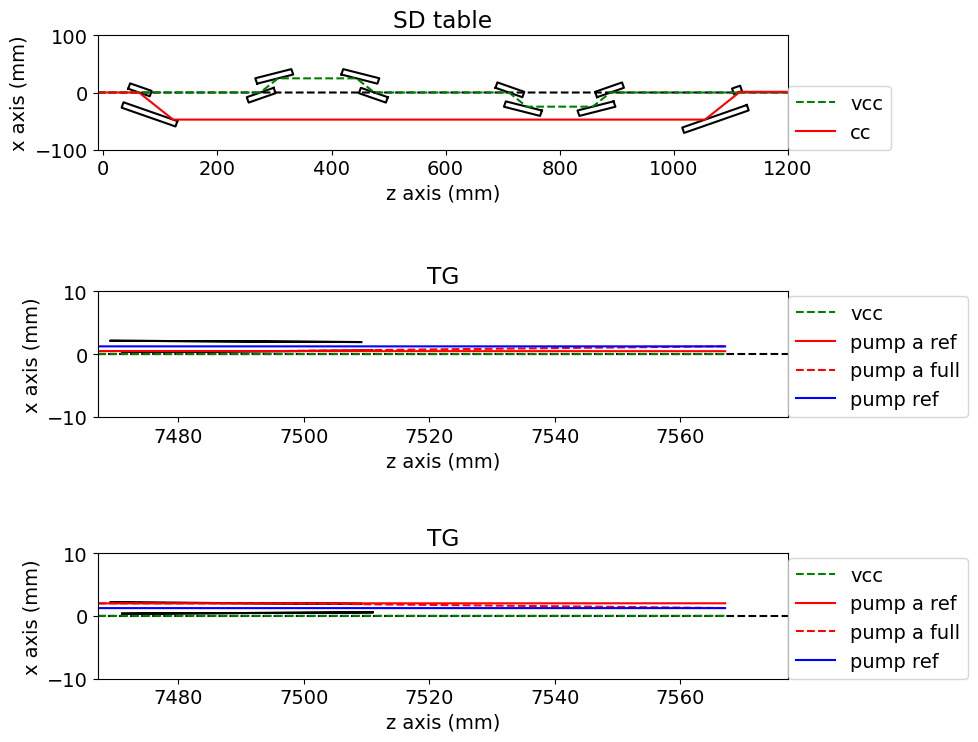

In [20]:
fig, axes = plt.subplots(ncols=1, nrows=3)

fig.set_figheight(8)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[0])

axes[0].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[0].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='cc')

axes[0].set_aspect("equal")
axes[0].set_ylim([-100, 100])
axes[0].set_xlim([-10, 1200])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("x axis (mm)")
axes[0].set_title('SD table')
axes[0].legend(loc=(1,0))


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[1])

axes[1].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[1].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='pump a ref')
axes[1].plot(pump_path2[0][:,2] / 1e3, pump_path2[0][:,1] / 1e3, linestyle='--', color='r', label='pump a full')
axes[1].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

axes[1].set_aspect("equal")
axes[1].set_ylim([-10, 10])
axes[1].set_xlim([pump_path1[0][-1,2] / 1e3 - 100, pump_path1[0][-1,2] / 1e3 + 10])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')
axes[1].legend(loc=(1,0))


axes[2].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[2])

axes[2].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[2].plot(pump_path3[0][:,2] / 1e3, pump_path3[0][:,1] / 1e3, color='r', label='pump a ref')
axes[2].plot(pump_path4[0][:,2] / 1e3, pump_path4[0][:,1] / 1e3, linestyle='--', color='r', label='pump a full')
axes[2].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')

axes[2].set_ylim([-10, 10])
axes[2].set_aspect("equal")
axes[2].set_xlim([pump_path1[0][-1,2] / 1e3 - 100, pump_path1[0][-1,2] / 1e3 + 10])
axes[2].set_xlabel("z axis (mm)")
axes[2].set_ylabel("x axis (mm)")
axes[2].set_title('TG')
axes[2].legend(loc=(1,0))

plt.tight_layout()

# Shift the mirror such that the interaction point is on the mirror

In [21]:
diff = pump_path2[0][-2] - exp.m2a.optics.surface_point
exp.m2a.x_umvr(diff[1])
exp.m2a.z_umvr(diff[2])

Motor moved to -8352.8378 um
Motor moved to 4493.8042 um


In [22]:
diff = pump_path4[0][-2] - exp.m2b.optics.surface_point
exp.m2b.x_umvr(diff[1])
exp.m2b.z_umvr(diff[2])

Motor moved to 10863.5694 um
Motor moved to 6483.4300 um


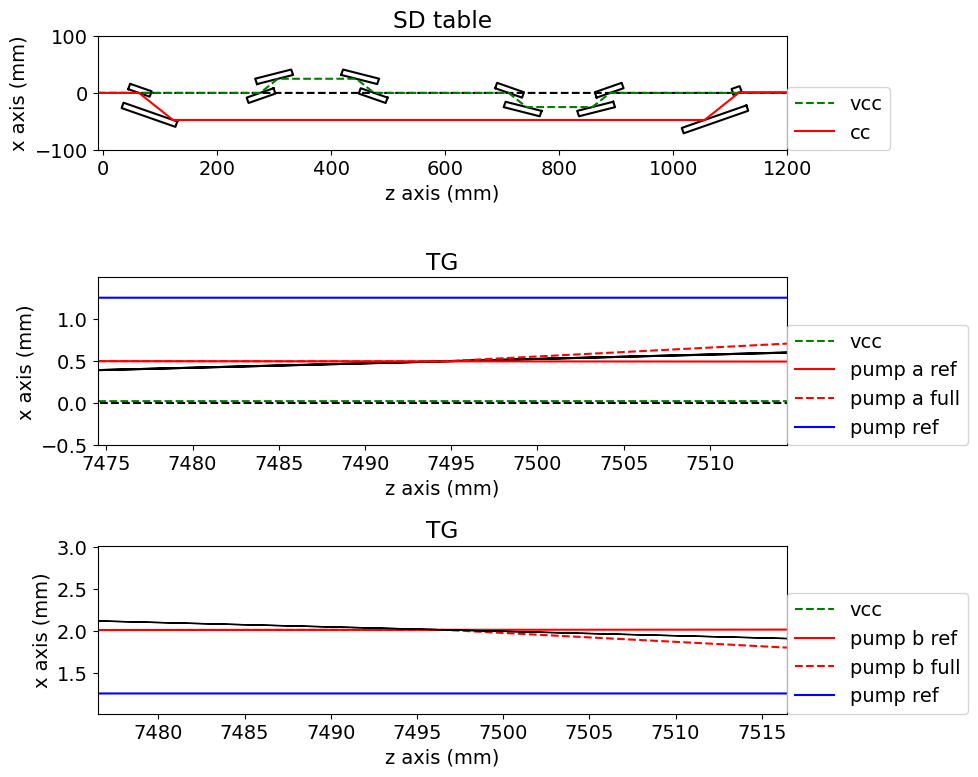

In [23]:
fig, axes = plt.subplots(ncols=1, nrows=3)

fig.set_figheight(8)
fig.set_figwidth(10)

axes[0].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[0])

axes[0].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[0].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='cc')

axes[0].set_aspect("equal")
axes[0].set_ylim([-100, 100])
axes[0].set_xlim([-10, 1200])
axes[0].set_xlabel("z axis (mm)")
axes[0].set_ylabel("x axis (mm)")
axes[0].set_title('SD table')
axes[0].legend(loc=(1,0))


axes[1].plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
exp.plot_optics(ax=axes[1])
axes[1].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[1].plot(pump_path1[0][:,2] / 1e3, pump_path1[0][:,1] / 1e3, color='r', label='pump a ref')
axes[1].plot(pump_path2[0][:,2] / 1e3, pump_path2[0][:,1] / 1e3, linestyle='--', color='r', label='pump a full')
axes[1].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')
axes[1].set_ylim([pump_path2[0][-2,1] / 1e3 - 1, pump_path2[0][-2,1] / 1e3 + 1])
axes[1].set_xlim([pump_path2[0][-2,2] / 1e3 - 20, pump_path2[0][-2,2] / 1e3 + 20])
axes[1].set_xlabel("z axis (mm)")
axes[1].set_ylabel("x axis (mm)")
axes[1].set_title('TG')
axes[1].legend(loc=(1,0))


axes[2].plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,1] / 1e3, 'g--', label='vcc')
axes[2].plot(pump_path3[0][:,2] / 1e3, pump_path3[0][:,1] / 1e3, color='r', label='pump b ref')
axes[2].plot(pump_path4[0][:,2] / 1e3, pump_path4[0][:,1] / 1e3, linestyle='--', color='r', label='pump b full')
axes[2].plot(pump_path[0][:,2] / 1e3, pump_path[0][:,1] / 1e3, color='b', label='pump ref')
axes[2].plot(exp.m2b.optics.boundary[:,2] / 1000,exp.m2b.optics.boundary[:,1]/1000, color='k', linewidth=1)
axes[2].set_ylim([pump_path4[0][-2,1] / 1e3 - 1, pump_path4[0][-2,1] / 1e3 + 1])
axes[2].set_xlim([pump_path4[0][-2,2] / 1e3 - 20, pump_path4[0][-2,2] / 1e3 + 20])
axes[2].set_xlabel("z axis (mm)")
axes[2].set_ylabel("x axis (mm)")
axes[2].set_title('TG')
axes[2].legend(loc=(1,0))

plt.tight_layout()

# Now begin to work with the probe beam

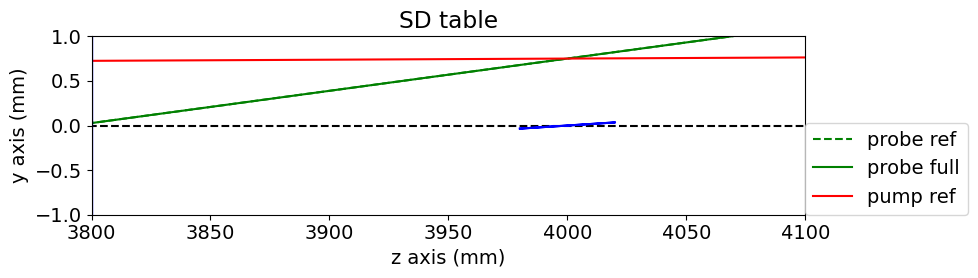

In [24]:
fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(probe_path1[0][:,2] / 1e3, probe_path1[0][:,0] / 1e3, 'g--', label='probe ref')
axes.plot(probe_path2[0][:,2] / 1e3, probe_path2[0][:,0] / 1e3, color='g', label='probe full')
axes.plot(pump_path[0][:,2] / 1e3, pump_path[0][:,0] / 1e3, color='r', label='pump ref')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_ylim([-1, 1])
axes.set_xlim([3800, 4100])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

# Move M1 such that the interaction point with the mirror is at location z=4e6

In [25]:
path_ref = exp.get_raytracing_trajectory(path="mono SD m1 yag")
_ = exp.m1.y_umvr(-100)
path_new = exp.get_raytracing_trajectory(path="mono SD m1 yag")

delta_100um = path_new[0][-2][2] - path_ref[0][-2][2]
total_diff = exp.m1.optics.surface_point[2] - path_new[0][-2][2]
print("Move the TG-a pulse {:.5f} um in x axis by moving m1y 100 um".format(delta_100um))
print("Need to move m1y {:.5f} um to compensate the total difference of {:.5f} um".format(
    total_diff / delta_100um * 100, total_diff))
_ = exp.m1.y_umvr(-total_diff / delta_100um * 100)

Motor moved to -100.0000 um
Move the TG-a pulse 53416.54475 um in x axis by moving m1y 100 um
Need to move m1y 651.23542 um to compensate the total difference of 347867.46162 um
Motor moved to -751.2354 um


In [26]:
path_ref = exp.get_raytracing_trajectory(path="mono SD m1 yag")

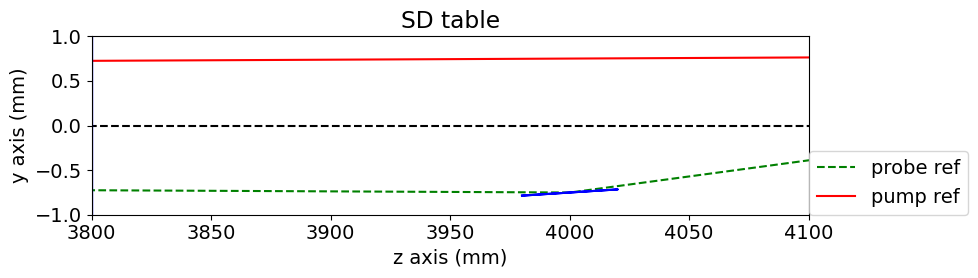

In [27]:
fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(path_ref[0][:,2] / 1e3, path_ref[0][:,0] / 1e3, 'g--', label='probe ref')
axes.plot(pump_path[0][:,2] / 1e3, pump_path[0][:,0] / 1e3, color='r', label='pump ref')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_ylim([-1, 1])
axes.set_xlim([3800, 4100])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

# Now need to worry about the silicon sample

In [28]:
probe_si_old = exp.get_raytracing_trajectory(path="mono SD m1 si yag")

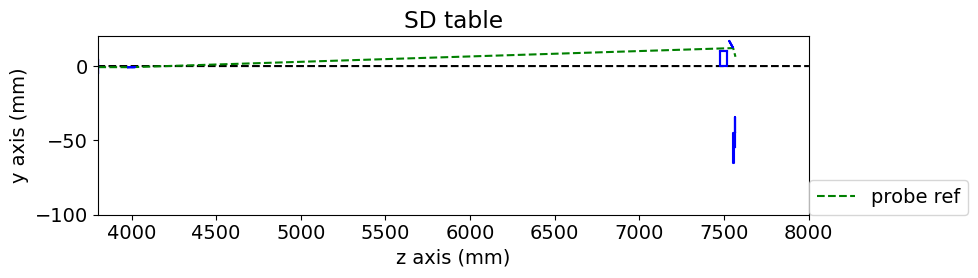

In [29]:
fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(3)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(probe_si_old[0][:,2] / 1e3, probe_si_old[0][:,0] / 1e3, 'g--', label='probe ref')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_ylim([-100, 20])
axes.set_xlim([3800, 8000])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

In [30]:
path_ref = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
_ = exp.si.y_umvr(100)
path_new = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
probe_pulse_ref = exp.get_raytracing_trajectory(path="mono SD yag")

delta_100um = path_new[0][-1][0] - path_ref[0][-1][0]
total_diff = probe_pulse_ref[0][-1][0] - path_new[0][-1][0]

print("Move the TG-a pulse {:.5f} um in x axis by moving m1y 100 um".format(delta_100um))
print("Need to move m1y {:.5f} um to compensate the total difference of {:.5f} um".format(total_diff / delta_100um * 100, total_diff))
_ = exp.si.y_umvr(total_diff / delta_100um * 100)

Motor moved to 100.0000 um
Move the TG-a pulse 209.00278 um in x axis by moving m1y 100 um
Need to move m1y -2510.60472 um to compensate the total difference of -5247.23355 um
Motor moved to -2410.6047 um


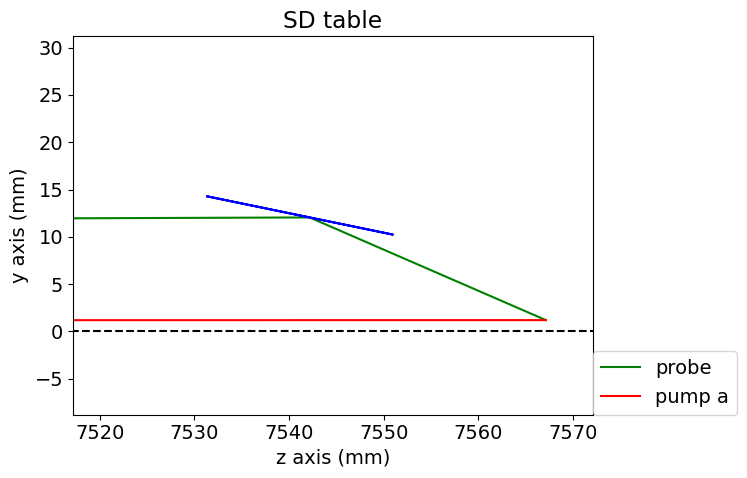

In [32]:
probe_si_new = exp.get_raytracing_trajectory(path="mono SD m1 si yag")
pump_path_new = exp.get_raytracing_trajectory(path="mono SD tga m2a yag")

fig, axes = plt.subplots(ncols=1, nrows=1)

fig.set_figheight(5)
fig.set_figwidth(10)

axes.plot(np.arange(-50, 10000), np.zeros(10050), c='k', linestyle='--')
axes.plot(probe_si_new[0][:,2] / 1e3, probe_si_new[0][:,0] / 1e3, 'g', label='probe')
axes.plot(pump_path_new[0][:,2] / 1e3, pump_path_new[0][:,0] / 1e3, 'r', label='pump a')
exp.plot_optics(ax=axes, axis='yz', color='blue')

axes.set_aspect("equal")
axes.set_ylim([probe_si_new[0][-1,0] / 1e3 - 10, probe_si_new[0][-1,0] / 1e3 + 30])
axes.set_xlim([probe_si_new[0][-1,2] / 1e3 - 50, probe_si_new[0][-1,2] / 1e3 + 5])
axes.set_xlabel("z axis (mm)")
axes.set_ylabel("y axis (mm)")
axes.set_title('SD table')
axes.legend(loc=(1,0))


plt.tight_layout()

### I think I need to create a better model now.
Also, clean up the algorithm a little bit